127 146
0 19


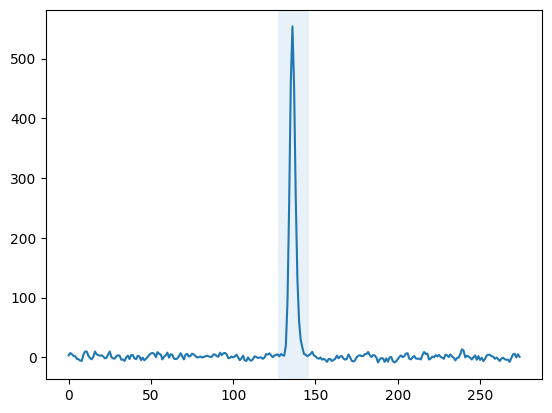

Configuration validated.
On- and off-burst spectra have been set.
Using 'equal_channels' sub-banding mode.
Sub-band analysis complete. Found results for 8/8 sub-bands.
Plotting the ACF fit for each sub-band...


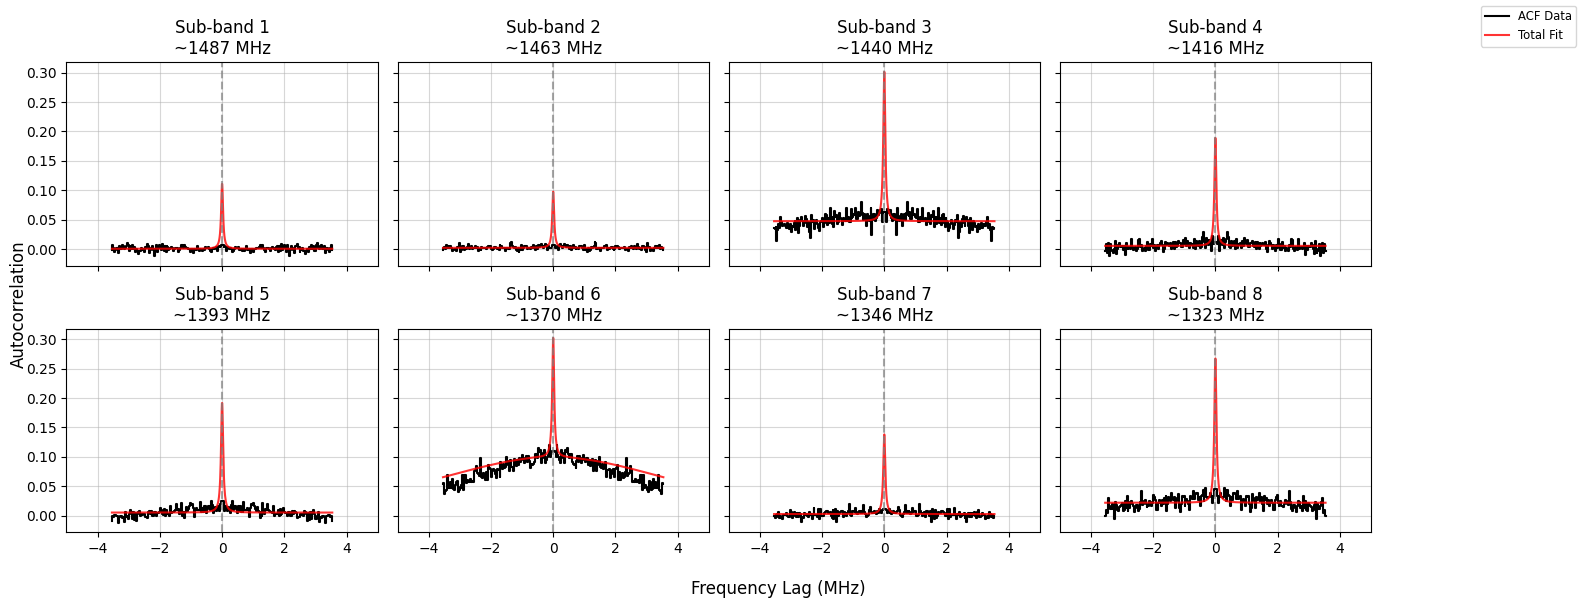

--- Frequency Dependence Fit: Component 1 ---
  Scintillation index (alpha) = -83.71 +/- 12265.74
--- Frequency Dependence Fit: Component 2 ---
  Scintillation index (alpha) = -0.16 +/- 18451.67


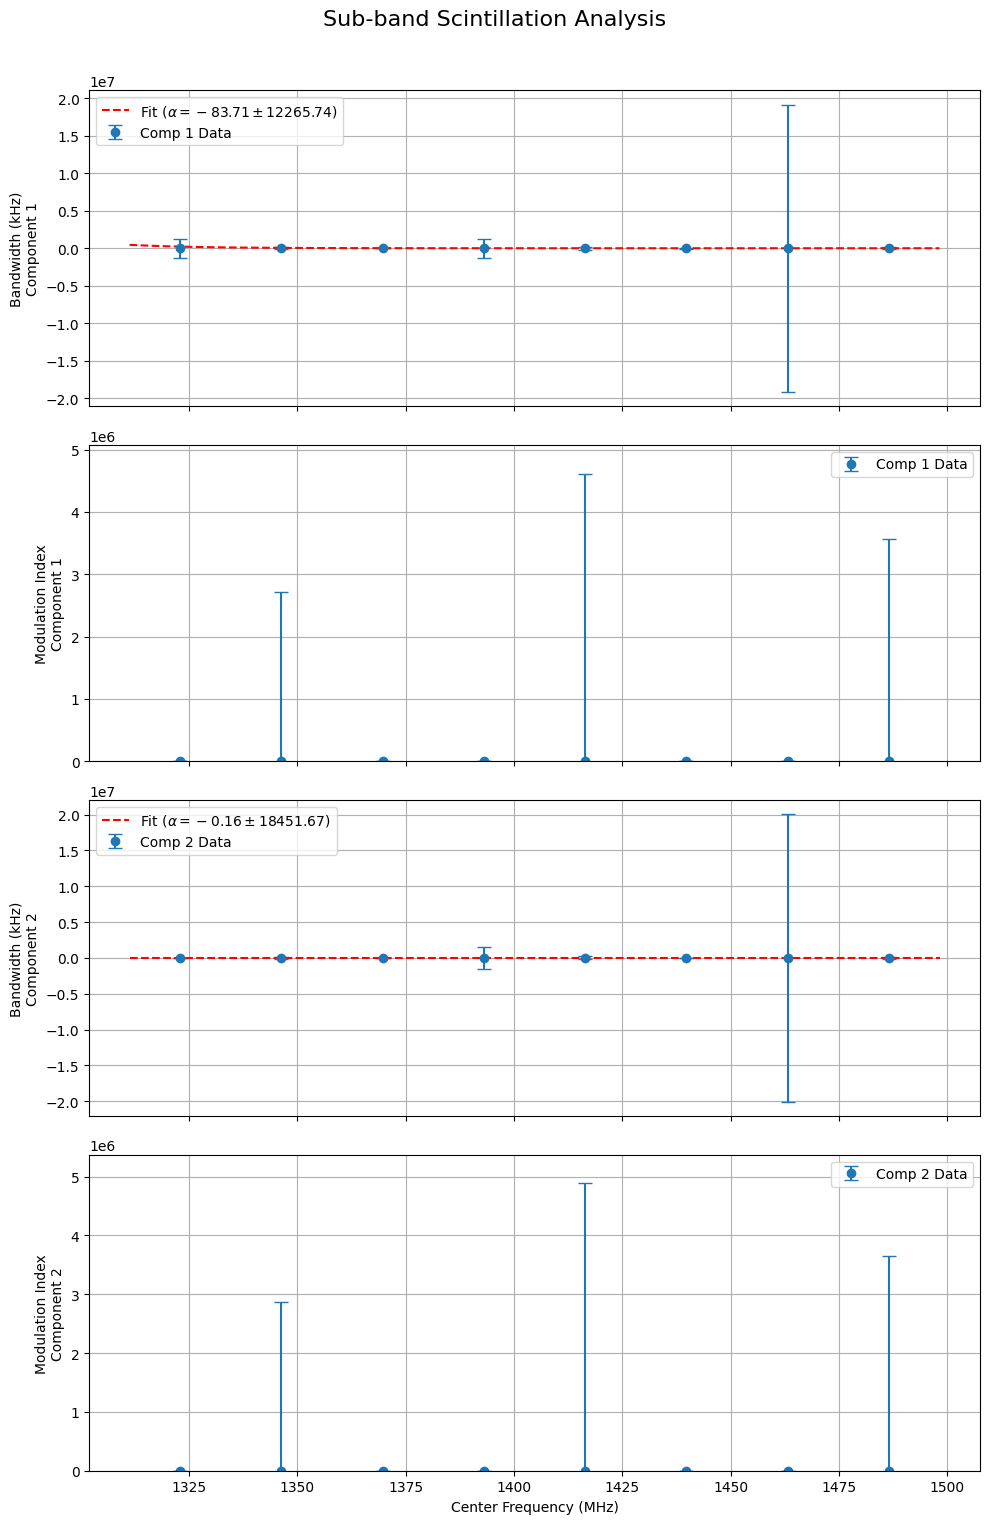

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import lmfit
from lmfit.models import ConstantModel
from scipy.optimize import curve_fit
from scipy.stats import linregress

from scint_toolkit import ScintillationAnalyzer

#dsa110_config = {
#    'nchan': 6144, 'freq_top_mhz': 1498.25, 'freq_bottom_mhz': 1311.25,
#    'bw_mhz': 187.5, 'tsamp_us': 32.768,
#}
# Simulate realistic data
#ntime = 512
#simulated_dyn_spec = np.random.randn(dsa110_config['nchan'], ntime) * 0.5
#on_pulse_bins = np.arange(ntime//2 - 20, ntime//2 + 20)
#off_pulse_bins = np.concatenate([np.arange(0, 50), np.arange(ntime-50, ntime)])

# Create a realistic spectrum to inject
#freqs = np.linspace(dsa110_config['freq_top_mhz'], dsa110_config['freq_bottom_mhz'], dsa110_config['nchan'])
#spec_shape = 5 * (freqs / 1400)**-1.0
#scint1 = 0.9 * np.sin(2*np.pi * freqs / 0.060) # 60 kHz scale
#scint2 = 1.2 * np.sin(2*np.pi * freqs / 0.003) # 3 kHz scale
#true_spectrum = spec_shape * (1 + scint1 + scint2)
#simulated_dyn_spec[:, on_pulse_bins] += true_spectrum[:, np.newaxis]


dsa110_config = {
    'nchan': 6144, 'freq_top_mhz': 1498.25, 'freq_bottom_mhz': 1311.25,
    'bw_mhz': 187.5, 'tsamp_us': 32.768,
}

dynspec = np.load('/arc/home/jfaber/baseband_morphologies/chime_dsa_codetections/data/DSA_bursts/casey_dsa_I_491_211_2500b_cntr_bpc.npy')
dynspec = dynspec[:, 1125:1400]
ntime = dynspec.shape[1]
on_pulse_bins = np.arange(ntime//2 - 10, ntime//2 + 10)
print(on_pulse_bins[0], on_pulse_bins[-1])
off_pulse_bins = np.arange(0, on_pulse_bins.shape[0]) #np.concatenate([np.arange(0, on_pulse_bins.shape[0]), np.arange(ntime-50, ntime)])
print(off_pulse_bins[0], off_pulse_bins[-1])

plt.plot(np.nansum(dynspec,axis=0))
plt.axvspan(on_pulse_bins[0], on_pulse_bins[-1], alpha=0.1)
plt.show()

# Create a realistic spectrum to inject
freqs = np.linspace(dsa110_config['freq_top_mhz'], dsa110_config['freq_bottom_mhz'], dsa110_config['nchan'])

# Define the number of components you want to fit
num_lorentz_components = 2

# Instantiate and run the full pipeline
analyzer = ScintillationAnalyzer(dynspec, dsa110_config)
analyzer.set_on_off_spectra(on_pulse_bins, off_pulse_bins)
analyzer.apply_rfi_mask(threshold_sigma=4)
analyzer.run_subband_analysis(
    num_subbands=8, 
    num_components=num_lorentz_components, 
    guess_fwhm_mhz=[0.10, 0.03],
    fit_lag_range_mhz=5,
    subband_mode='equal_channels'
)

# --- CALL THE NEW DIAGNOSTIC PLOT ---
print("Plotting the ACF fit for each sub-band...")
analyzer.plot_subband_acf_fits(lag_extent_mhz=5)

# Now run the downstream analysis, passing num_components explicitly
analyzer.fit_frequency_dependence(num_components=num_lorentz_components)
analyzer.plot_subband_results(num_components=num_lorentz_components)


In [2]:
!pip install lmfit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 63.9 MB/s eta 0:00:00
